# 00 · Python 环境搭建 & 验证

欢迎来到 `mini-tests`！在这个系列中，你将通过 Jupyter Notebook 动手实践量子化学中的各种方法。

本 notebook 的目标：
1. 了解如何搭建 Python 科学计算环境
2. 配置 `pyscf` 等核心依赖
3. 运行几个简单例子，确认环境一切正常

---

## 1 · Python 环境搭建

做科学计算，环境管理是第一关。这里介绍两种主流方案：**uv** 和 **conda**。

### 方案 A: uv（本项目的选择）

[uv](https://github.com/astral-sh/uv) 是 Rust 写的 Python 包管理器，速度快、使用简单，适合现代 Python 项目。

> **Windows 用户注意：PySCF 不支持 Windows**
> 
> PySCF 依赖一些 Unix 底层的库，无法直接在 Windows 上运行。因此 Windows 用户需要先安装 WSL (Windows Subsystem for Linux)，在 WSL 中完成所有操作。
> 
> **安装 WSL（约 15 分钟）：**
> 1. 以管理员身份打开 PowerShell，运行：
> ```powershell
> wsl --install
> ```
> 这会默认安装 Ubuntu。
> 2. 重启电脑，按提示设置 Ubuntu 用户名和密码。
> 3. 之后所有操作都在 Ubuntu 终端中进行，和 Linux 用户完全一致。
> 
> 参考资料：[微软 WSL 官方文档](https://learn.microsoft.com/zh-cn/windows/wsl/install)

**Step 1: 安装 uv**

macOS / Linux:
```bash
curl -LsSf https://astral.sh/uv/install.sh | sh
```

或者用 Homebrew (macOS):
```bash
brew install uv
```

安装后验证：
```bash
uv --version
```

**Step 2: 创建项目 & 安装依赖**

```bash
# 初始化新项目
uv init my-quantum-project
cd my-quantum-project

# 添加依赖（uv 会自动处理虚拟环境和依赖解析）
uv add jupyter ipykernel numpy scipy matplotlib pyscf

# 启动 Jupyter Lab
uv run jupyter lab
```

**uv 的核心优势：**
- 比 pip 快 10-100 倍
- 自动创建和管理虚拟环境，不需要手动 `python -m venv`
- `uv.lock` 锁文件确保所有人用完全相同的依赖版本
- 一条 `uv run` 自动在正确的环境中执行

**Step 3: 克隆本项目，直接开始**

本项目已经配置好了 `pyproject.toml`，你只需要：

```bash
git clone <this-repo>
cd mini-tests
uv sync          # 一键安装所有依赖
uv run jupyter lab
```

**Step 1: 安装 conda**

推荐安装 [Miniconda](https://docs.anaconda.com/miniconda/)（轻量版 conda，只含基础包）：

- **macOS / Linux**: 从 [Miniconda 下载页](https://docs.anaconda.com/miniconda/install/) 下载对应安装脚本，或直接：
```bash
# macOS (Apple Silicon)
curl -L https://repo.anaconda.com/miniconda/Miniconda3-latest-MacOSX-arm64.sh -o Miniconda3.sh
# Linux
curl -L https://repo.anaconda.com/miniconda/Miniconda3-latest-Linux-x86_64.sh -o Miniconda3.sh

bash Miniconda3.sh
```

- **Windows (WSL 中)**: 使用 Linux 的安装方式。

安装完成后**重启终端**，验证：
```bash
conda --version
```

### 国内用户：换源加速

国内直接访问 PyPI / conda 官方源可能很慢，建议换成**清华大学开源镜像站 (TUNA)**。

#### pip / uv 换源

uv 默认使用 PyPI，可以通过环境变量指定镜像：

```bash
# 临时使用（单次）
uv pip install -i https://pypi.tuna.tsinghua.edu.cn/simple <package>

# 永久生效（推荐）：写入配置文件
# Linux / macOS / WSL:
echo 'export UV_INDEX_URL="https://pypi.tuna.tsinghua.edu.cn/simple"' >> ~/.bashrc
# 或 ~/.zshrc（如果用 zsh）
source ~/.bashrc
```

如果用原生 pip（不用 uv）：

```bash
pip config set global.index-url https://pypi.tuna.tsinghua.edu.cn/simple
```

#### conda 换源

```bash
# 创建 ~/.condarc 文件
conda config --set show_channel_urls yes
# 修改～/.condarc 为
channels:
- defaults
show_channel_urls: true
default_channels:
- https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/main
- https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/r
- https://mirrors.tuna.tsinghua.edu.cn/anaconda/pkgs/msys2
custom_channels:
conda-forge: https://mirrors.tuna.tsinghua.edu.cn/anaconda/cloud
pytorch: https://mirrors.tuna.tsinghua.edu.cn/anaconda/cloud
# 查看是否生效
conda config --show channels
```

> 如果清华源不可用，备选：阿里云 (`mirrors.aliyun.com/pypi/simple`)、中科大 (`pypi.mirrors.ustc.edu.cn/simple`)、腾讯云 (`mirrors.cloud.tencent.com/pypi/simple`)。

**Step 2: 创建环境 & 安装依赖**

```bash
# 创建名为 quantum 的环境，指定 Python 版本
conda create -n quantum python=3.12

# 激活环境
conda activate quantum

# 安装依赖（conda 优先，没有的用 pip 补）
conda install jupyter numpy scipy matplotlib
pip install pyscf

# 启动 Jupyter
jupyter lab
```

**conda vs uv 对比：**

|  | uv | conda |
|------|-----|-------|
| 速度 |  极快 (Rust) |  较慢 |
| 虚拟环境 | 自动管理 | 手动 activate |
| 非 Python 包 |  不支持 |  支持 |
| 生态成熟度 | 新兴，活跃开发 | 非常成熟 |
| 本项目 |  已配置 | 需手动 setup |

---

## 2 · 环境验证

不管用哪种方案搭好了环境，下面运行几个例子确认一切正常。

如果任何一步报错，回头检查环境配置或依赖安装。

### 2.1 Python & 关键库

In [10]:
import sys
print(f"Python 版本: {sys.version}")
assert sys.version_info >= (3, 10), "Python 版本过低，需要 >= 3.10"
print("Python 版本 OK")

Python 版本: 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
Python 版本 OK


In [11]:
import numpy as np
print(f"NumPy 版本: {np.__version__}")

import scipy
print(f"SciPy 版本: {scipy.__version__}")

import matplotlib
print(f"Matplotlib 版本: {matplotlib.__version__}")

print("基础科学计算库 OK")

NumPy 版本: 2.5.0
SciPy 版本: 1.18.0
Matplotlib 版本: 3.11.0
基础科学计算库 OK


### 2.2 PySCF: 跑一个最经典的计算

用 `pyscf` 对水分子做 RHF/cc-pVDZ 计算——这大概是量子化学的 "Hello, world!"。

In [12]:
from pyscf import gto, scf

# 定义水分子（坐标单位: Angstrom）
mol = gto.M(
atom='''
O   0.000000   0.000000   0.000000
H   0.758602   0.000000   0.504284
H   0.758602   0.000000  -0.504284
''',
basis='cc-pVDZ',
verbose=4,  # 打印详细信息
)

# RHF 计算
mf = scf.RHF(mol)
mf.kernel()

print(f"\n RHF 能量 = {mf.e_tot:.8f} Hartree")
print("PySCF RHF 计算 OK")

System: uname_result(system='Darwin', node='sunxinyudeMacBook-Air.local', release='25.5.0', version='Darwin Kernel Version 25.5.0: Mon Apr 27 20:38:00 PDT 2026; root:xnu-12377.121.6~2/RELEASE_ARM64_T8103', machine='arm64')  Threads 1
Python 3.12.13 (main, Mar  3 2026, 12:39:30) [Clang 17.0.0 (clang-1700.6.3.2)]
numpy 2.5.0  scipy 1.18.0  h5py 3.16.0
Date: Wed Jul  1 20:38:08 2026
PySCF version 2.13.1
PySCF path  /Users/sunxinyu/develop/mini-tests/.venv/lib/python3.12/site-packages/pyscf

[CONFIG] conf_file None
[INPUT] verbose = 4
[INPUT] num. atoms = 3
[INPUT] num. electrons = 10
[INPUT] charge = 0
[INPUT] spin (= nelec alpha-beta = 2S) = 0
[INPUT] symmetry False subgroup None
[INPUT] Mole.unit = angstrom
[INPUT] Symbol           X                Y                Z      unit          X                Y                Z       unit  Magmom
[INPUT]  1 O      0.000000000000   0.000000000000   0.000000000000 AA    0.000000000000   0.000000000000   0.000000000000 Bohr   0.0
[INPUT]  2 H    

### 2.3 画个图确认 Matplotlib 正常

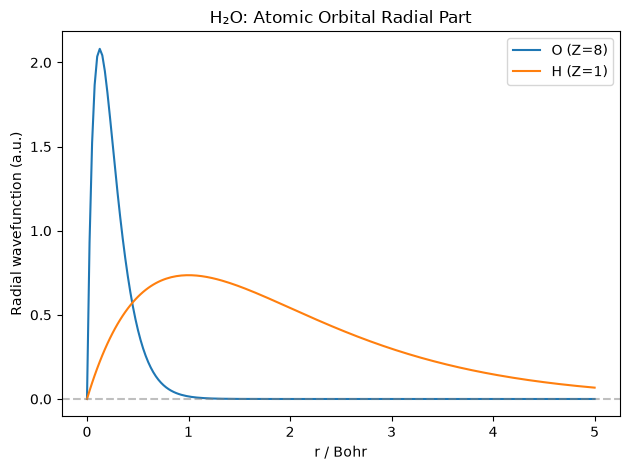

Matplotlib 画图 OK


In [13]:
import matplotlib.pyplot as plt
import numpy as np

# 画出水分子的 1s 类轨道波函数的径向部分（a.u.）
r = np.linspace(0, 5, 200)
for Z, label in [(8, 'O'), (1, 'H')]:
    psi = 2 * Z**1.5 * r * np.exp(-Z * r)  # 2p 径向部分的简化a.u.
    plt.plot(r, psi, label=f'{label} (Z={Z})')

plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5)
plt.xlabel('r / Bohr')
plt.ylabel('Radial wavefunction (a.u.)')
plt.title('H₂O: Atomic Orbital Radial Part')
plt.legend()
plt.tight_layout()
plt.show()
print("Matplotlib 画图 OK")

### 2.4 NumPy/SCF 积分小练习

一个快速验证：用 PySCF 读取分子积分的 overlap 矩阵，检查本征值是否 > 0（基组线性无关的充要条件）。

In [14]:
# 获取 overlap 矩阵
S = mol.intor('int1e_ovlp')

# 对角化，检查最小本征值
eigvals = np.linalg.eigvalsh(S)

print(f"Overlap 矩阵维度: {S.shape[0]} x {S.shape[1]}")
print(f"最小本征值: {eigvals.min():.6f}")
print(f"最大本征值: {eigvals.max():.6f}")

assert eigvals.min() > 0, "基组可能存在线性相关！"
print("Overlap 矩阵正定，基组 OK")

Overlap 矩阵维度: 24 x 24
最小本征值: 0.031924
最大本征值: 4.153496
Overlap 矩阵正定，基组 OK


---

## 3 · 准备好了！

如果以上所有 cell 都跑通了（没有报错），你的环境已经就绪，可以开始后续模块了。

Have fun!